In [3]:
from google.colab import files
import zipfile
import os

uploaded = files.upload()  # this will open a file picker

Saving archive.zip to archive.zip


In [4]:
import zipfile
import os

with zipfile.ZipFile("archive.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

# Check structure
for root, dirs, files in os.walk("dataset"):
    level = root.replace("dataset", '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        subindent = ' ' * 2 * (level + 1)
        print(f'{subindent}{len(files)} files')

dataset/
  0 files
  brain_tumor_dataset/
    0 files
    yes/
    no/
  yes/
    155 files
  no/
    98 files


✅ Loaded: (253, 128, 128, 3), Labels: (253,)
   Tumor: 155, No Tumor: 98
Train: (177, 128, 128, 3), Val: (38, 128, 128, 3), Test: (38, 128, 128, 3)
Class Weights: {0: np.float64(1.2826086956521738), 1: np.float64(0.8194444444444444)}


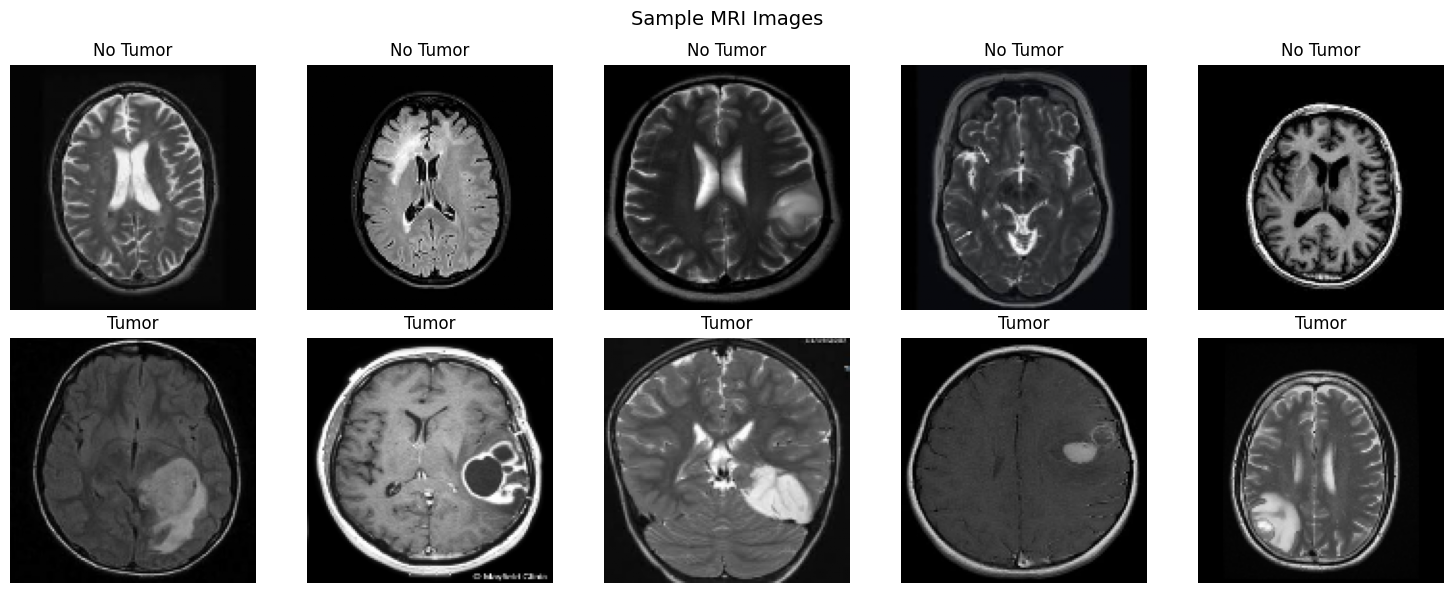

✅ Preprocessing done!


In [5]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight

DATASET_PATH = "dataset"
IMG_SIZE = 128

def load_data(path):
    X, y = [], []
    classes = {"no": 0, "yes": 1}

    for label, value in classes.items():
        folder = os.path.join(path, label)
        for img_file in os.listdir(folder):
            img_path = os.path.join(folder, img_file)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            X.append(img)
            y.append(value)

    return np.array(X), np.array(y)

X, y = load_data(DATASET_PATH)
print(f"✅ Loaded: {X.shape}, Labels: {y.shape}")
print(f"   Tumor: {sum(y==1)}, No Tumor: {sum(y==0)}")

X = X / 255.0

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(weights))
print(f"Class Weights: {class_weights}")

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes[0]):
    idx = np.where(y_train == 0)[0][i]
    ax.imshow(X_train[idx])
    ax.set_title("No Tumor")
    ax.axis("off")
for i, ax in enumerate(axes[1]):
    idx = np.where(y_train == 1)[0][i]
    ax.imshow(X_train[idx])
    ax.set_title("Tumor")
    ax.axis("off")
plt.suptitle("Sample MRI Images", fontsize=14)
plt.tight_layout()
plt.show()

print("✅ Preprocessing done!")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 16,829,633 (64.20 MB)

 Trainable params: 2,114,433 (8.07 MB)

 Non-trainable params: 14,715,200 (56.13 MB)

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5314 - loss: 0.8994   
Epoch 1: val_loss improved from None to 1.04413, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.5085 - loss: 0.9080 - val_accuracy: 0.3684 - val_loss: 1.0441
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.5718 - loss: 0.7633
Epoch 2: val_loss improved from 1.04413 to 1.01452, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 220ms/step - accuracy: 0.5819 - loss: 0.7173 - val_accuracy: 0.3684 - val_loss: 1.0145
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.6754 - loss: 0.6544
Epoch 3: val_loss improved from 1.01452 to 0.95898, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 231ms/step - accuracy: 0.6497 - loss: 0.6373 - val_accuracy: 0.3684 - val_loss: 0.95

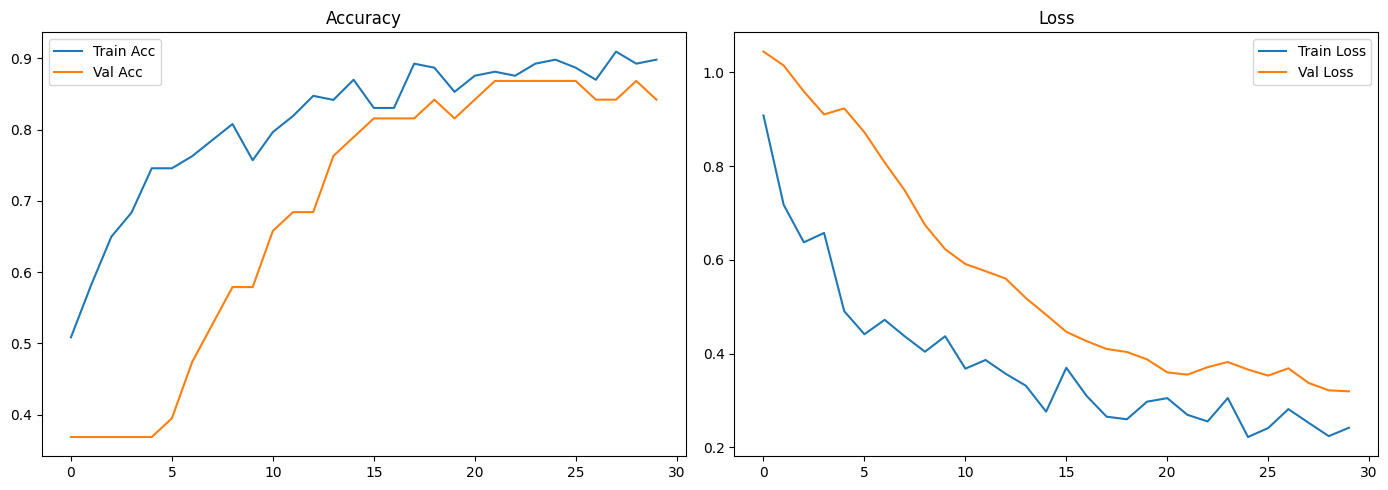

✅ Curves plotted!


In [6]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ─────────────────────────────────────────
# 1. DATA AUGMENTATION
# ─────────────────────────────────────────
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
datagen.fit(X_train)

# ─────────────────────────────────────────
# 2. BUILD MODEL
# ─────────────────────────────────────────
base_model = VGG16(weights="imagenet", include_top=False, input_shape=(128, 128, 3))
base_model.trainable = False

x = base_model.output
x = Flatten()(x)
x = Dense(256, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(64, activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss="binary_crossentropy",
              metrics=["accuracy"])

model.summary()

# ─────────────────────────────────────────
# 3. TRAIN
# ─────────────────────────────────────────
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint("best_model.keras", save_best_only=True, verbose=1)
]

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val),
    epochs=30,
    callbacks=callbacks,
    class_weight=class_weights
)

print("✅ Training done!")

# ─────────────────────────────────────────
# 4. PLOT TRAINING CURVES
# ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["accuracy"],     label="Train Acc")
axes[0].plot(history.history["val_accuracy"], label="Val Acc")
axes[0].set_title("Accuracy")
axes[0].legend()

axes[1].plot(history.history["loss"],     label="Train Loss")
axes[1].plot(history.history["val_loss"], label="Val Loss")
axes[1].set_title("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()
print("✅ Curves plotted!")

2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step
📊 Classification Report:
              precision    recall  f1-score   support

    No Tumor       0.91      0.67      0.77        15
       Tumor       0.81      0.96      0.88        23

    accuracy                           0.84        38
   macro avg       0.86      0.81      0.82        38
weighted avg       0.85      0.84      0.84        38

AUC-ROC Score: 0.8348


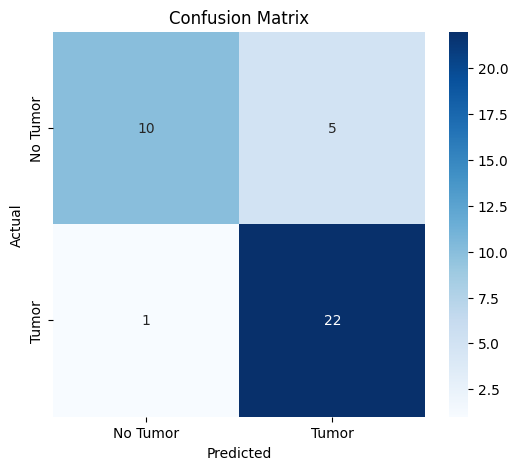

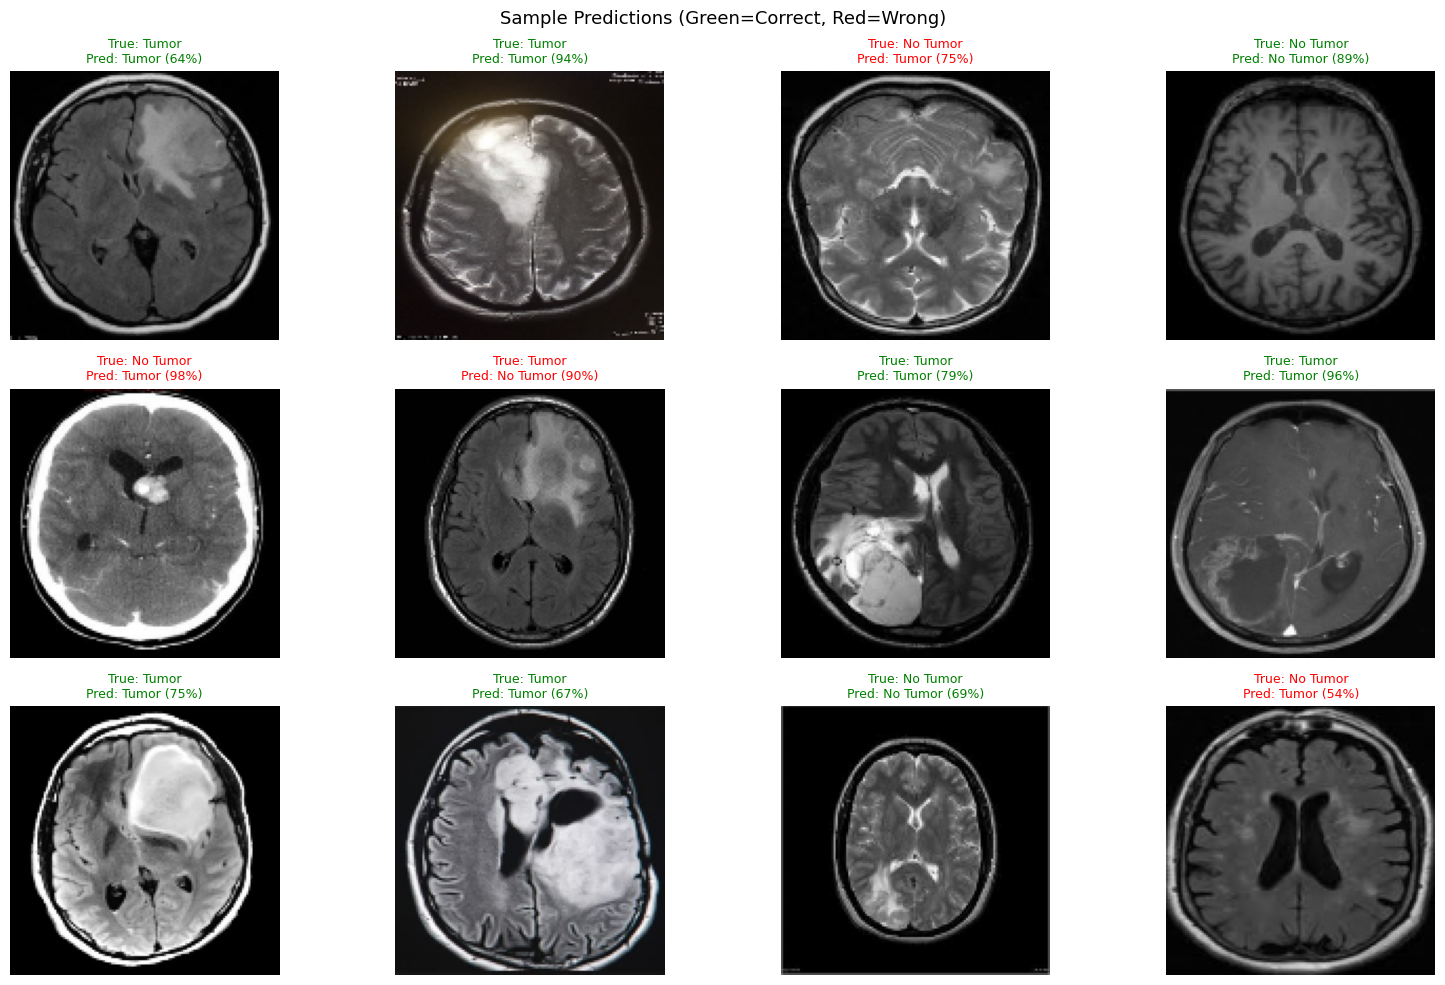

In [7]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import seaborn as sns

# ─────────────────────────────────────────
# 1. EVALUATE ON TEST SET
# ─────────────────────────────────────────
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print("📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=["No Tumor", "Tumor"]))
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_pred_prob):.4f}")

# ─────────────────────────────────────────
# 2. CONFUSION MATRIX
# ─────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Tumor", "Tumor"],
            yticklabels=["No Tumor", "Tumor"])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# ─────────────────────────────────────────
# 3. SHOW SAMPLE PREDICTIONS
# ─────────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i in range(12):
    axes[i].imshow(X_test[i])
    true_label = "Tumor" if y_test[i] == 1 else "No Tumor"
    pred_label = "Tumor" if y_pred[i] == 1 else "No Tumor"
    confidence = y_pred_prob[i][0] if y_pred[i] == 1 else 1 - y_pred_prob[i][0]

    color = "green" if true_label == pred_label else "red"
    axes[i].set_title(f"True: {true_label}\nPred: {pred_label} ({confidence:.0%})",
                      color=color, fontsize=9)
    axes[i].axis("off")

plt.suptitle("Sample Predictions (Green=Correct, Red=Wrong)", fontsize=13)
plt.tight_layout()
plt.show()